In [9]:
# Cell 1 — imports and helpers

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import BoundaryNorm
from matplotlib import cm

plt.rcParams["figure.dpi"] = 120

X_COL = "proj_x"
Y_COL = "proj_y"
RISK_COL = "risk_0_2m"


def raster_from_df(df, x_col, y_col, value_col):
    """
    Convert a pixel table into a 2D raster suitable for imshow.

    Assumes each row corresponds to one raster pixel.
    If duplicate x/y pairs exist, later rows overwrite earlier ones.
    """
    sub = df[[x_col, y_col, value_col]].copy()
    sub = sub.dropna(subset=[x_col, y_col])

    x_vals = np.sort(sub[x_col].unique())
    y_vals = np.sort(sub[y_col].unique())

    x_codes = pd.Categorical(sub[x_col], categories=x_vals, ordered=True).codes
    y_codes = pd.Categorical(sub[y_col], categories=y_vals, ordered=True).codes

    raster = np.full((len(y_vals), len(x_vals)), np.nan, dtype=np.float32)
    raster[y_codes, x_codes] = sub[value_col].to_numpy(dtype=np.float32)

    extent = [x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()]
    return raster, extent


def plot_raster(ax, raster, extent, title, cmap_name, vmin=None, vmax=None, cbar_label=None):
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad("white")

    im = ax.imshow(
        raster,
        origin="lower",
        extent=extent,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
        aspect="equal",
    )
    ax.set_title(title)
    ax.set_xlabel(X_COL)
    ax.set_ylabel(Y_COL)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if cbar_label:
        cbar.set_label(cbar_label)

    return im

In [2]:
# Cell 2 — load the Severn reference terrain file

terrain_df = pd.read_parquet("C:/Users/user/OneDrive/Documents/Github/Flood Risk Hackathon/flood-risk-hackathon/Data/cleaned/severn_terrain_ready.parquet")

terrain_df.head()

,proj_y,proj_x,dtm_zscore,log_flow_acc,imd,waw,clc_type,risk_0_2m,risk_0_3m,risk_0_6m,risk_0_9m,risk_1_2m,is_waterway,era5_pixel_idx
0,3186250.0,3461530.0,1.868489,3.743047,0.0,0,211,0,0,0,0,0,0,0
1,3186270.0,3461530.0,1.869868,3.970448,0.0,0,211,0,0,0,0,0,0,0
2,3186290.0,3461290.0,1.224782,3.607388,0.0,0,313,0,0,0,0,0,0,0
3,3186290.0,3461410.0,1.556973,6.450094,0.0,0,313,0,0,0,0,0,0,0
4,3186290.0,3461430.0,1.649325,6.410316,0.0,0,313,0,0,0,0,0,0,0


# Ground Truth Map

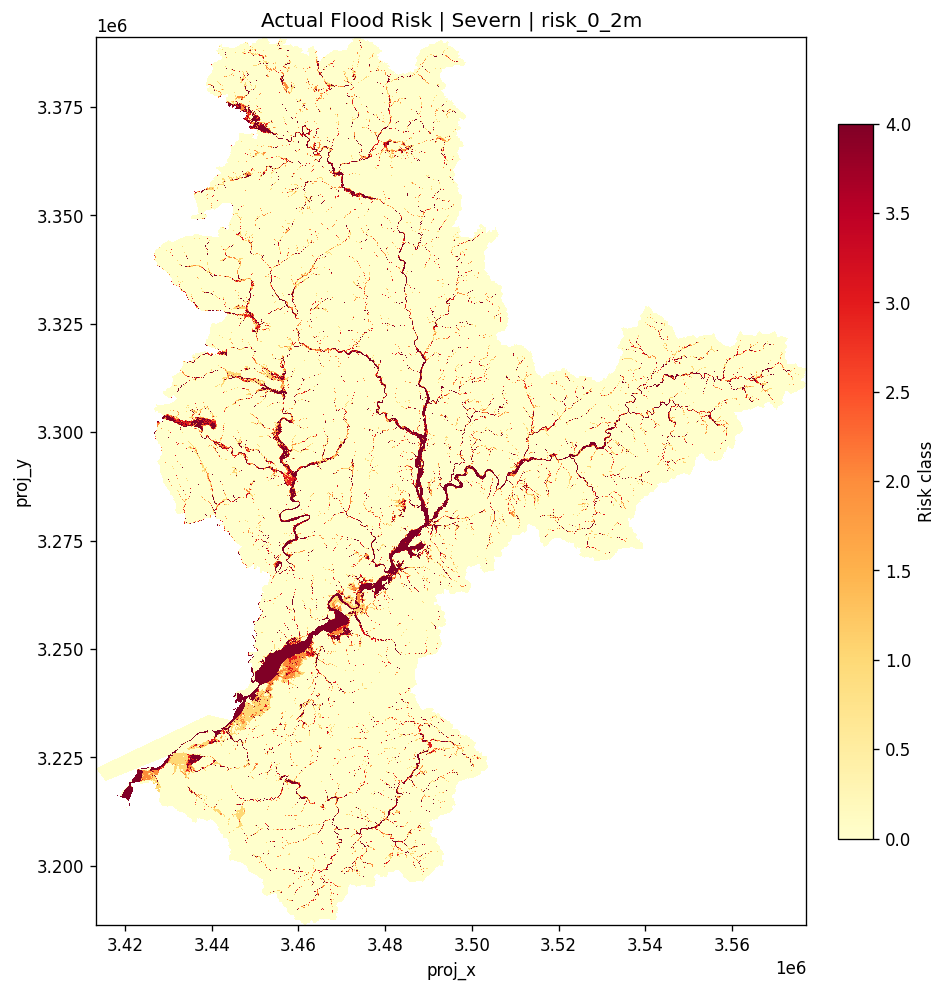

In [3]:
# Cell 3 — Visual 1: actual flood risk raster

risk_raster, extent = raster_from_df(terrain_df, X_COL, Y_COL, RISK_COL)

fig, ax = plt.subplots(figsize=(8, 10))
plot_raster(
    ax,
    risk_raster,
    extent,
    title="Actual Flood Risk | Severn | risk_0_2m",
    cmap_name="YlOrRd",
    vmin=0,
    vmax=4,
    cbar_label="Risk class",
)

plt.tight_layout()
plt.show()


### Create visualizations for Wetness, Flow Accumulation and Elevation Reference as Engineered Features

C:\Users\user\AppData\Local\Temp\ipykernel_20600\2197281085.py:97: RuntimeWarning: Mean of empty slice
  return np.nanmean(a.reshape(h2 // step, step, w2 // step, step), axis=(1, 3))
C:\Users\user\AppData\Local\Temp\ipykernel_20600\2197281085.py:104: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(a.reshape(h2 // step, step, w2 // step, step), axis=(1, 3))
C:\Users\user\AppData\Local\Temp\ipykernel_20600\2197281085.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(classes)).copy()


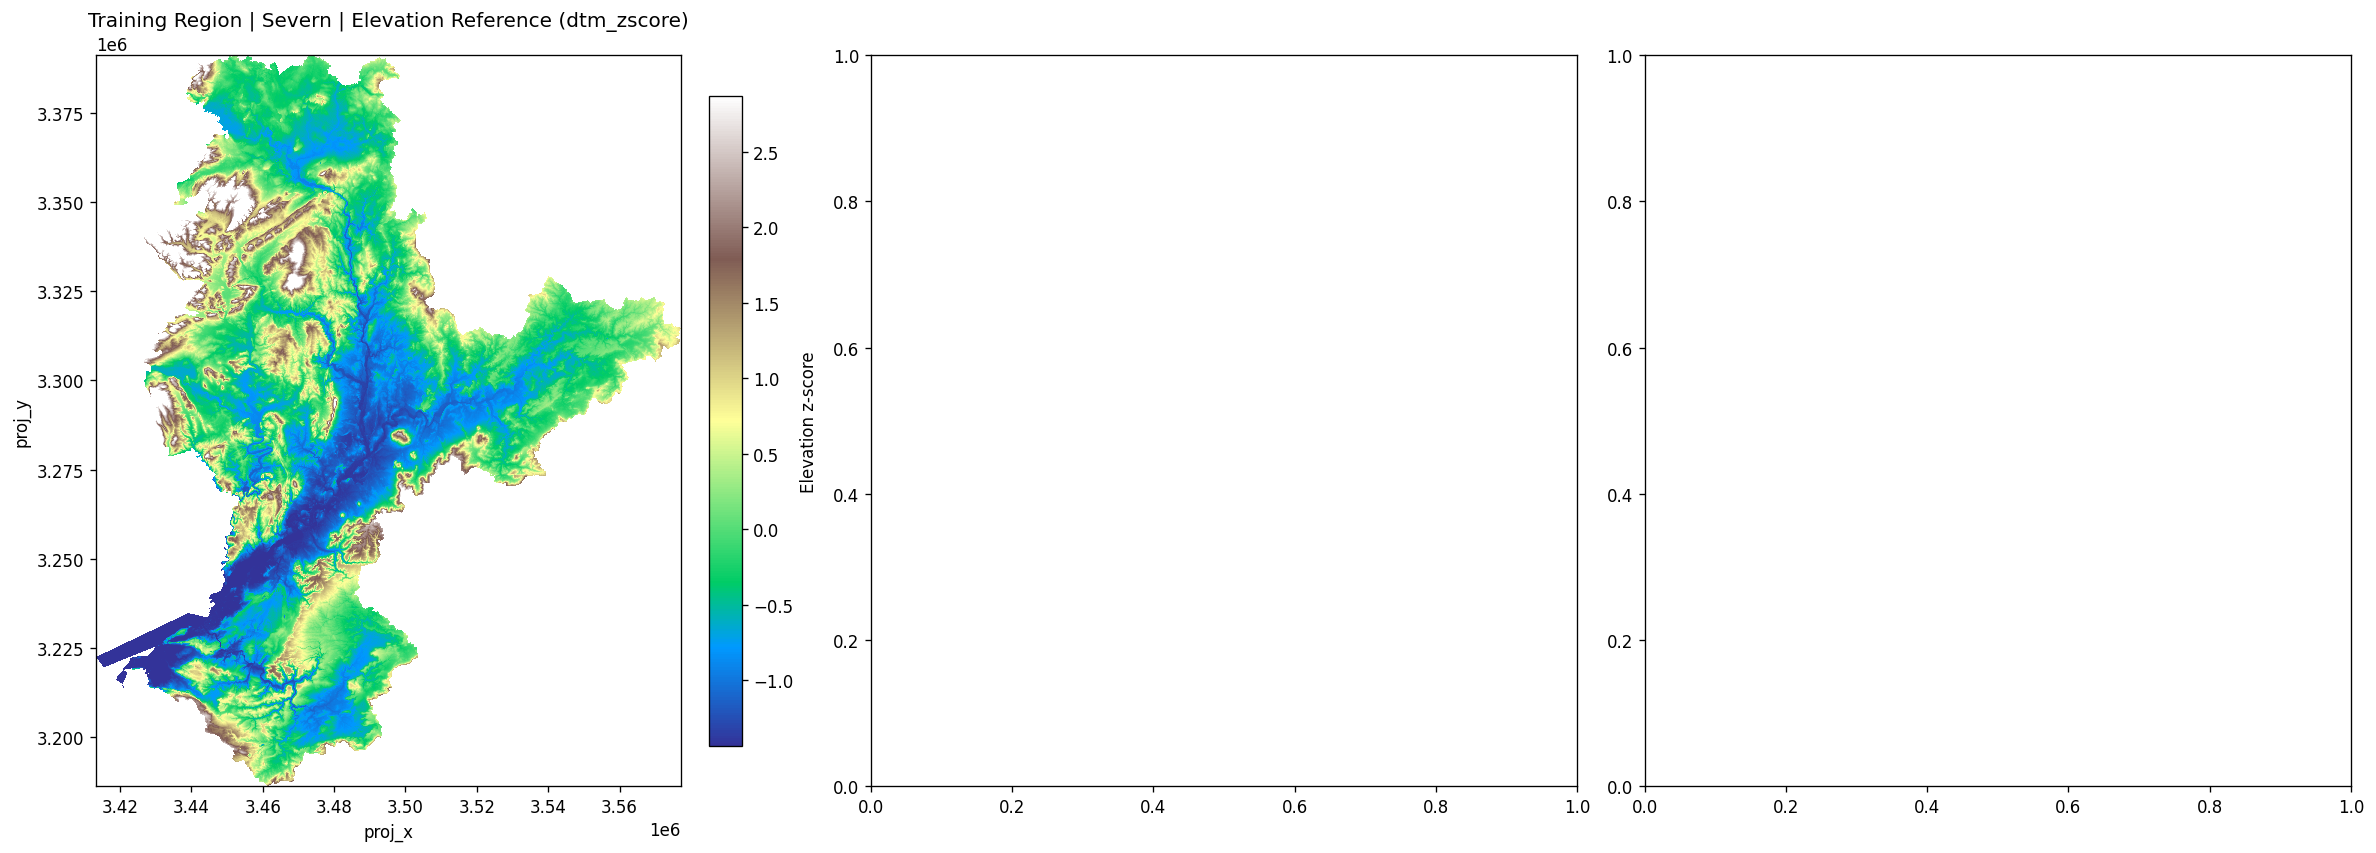

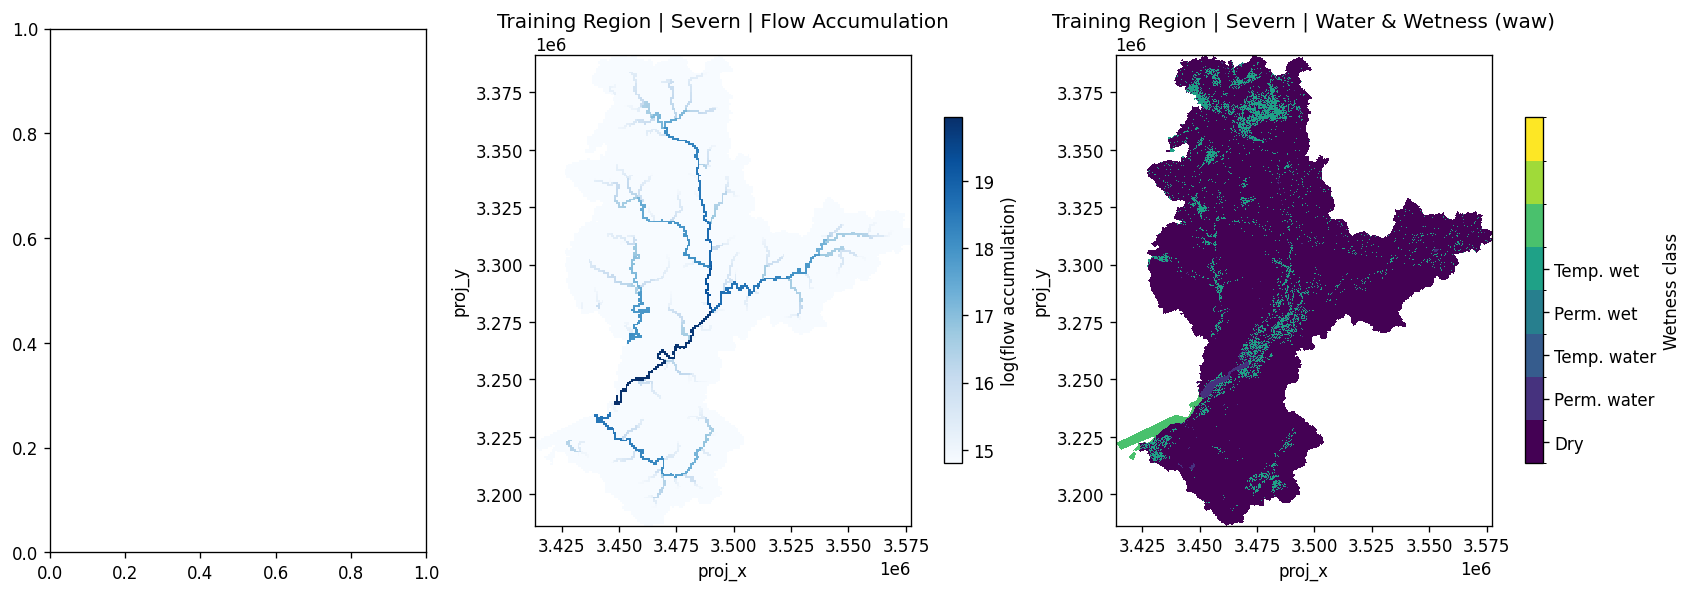

In [7]:

# Load TRAINING region
severn_df = pd.read_parquet("C:\\Users\\user\\OneDrive\\Documents\\Github\\Flood Risk Hackathon\\flood-risk-hackathon\\Data\\cleaned\\severn_terrain_ready.parquet")

# --- helpers ---
def raster_from_df(df, x_col, y_col, value_col):
    sub = df[[x_col, y_col, value_col]].copy().dropna(subset=[x_col, y_col])

    x_vals = np.sort(sub[x_col].unique())
    y_vals = np.sort(sub[y_col].unique())

    x_codes = pd.Categorical(sub[x_col], categories=x_vals, ordered=True).codes
    y_codes = pd.Categorical(sub[y_col], categories=y_vals, ordered=True).codes

    raster = np.full((len(y_vals), len(x_vals)), np.nan, dtype=np.float32)
    raster[y_codes, x_codes] = sub[value_col].to_numpy(dtype=np.float32)

    extent = [x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()]
    return raster, extent


def plot_continuous(ax, raster, extent, title, cmap_name, cbar_label, vmin=None, vmax=None):
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad("white")

    im = ax.imshow(
        raster,
        origin="lower",
        extent=extent,
        cmap=cmap,
        interpolation="nearest",
        aspect="equal",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_title(title)
    ax.set_xlabel("proj_x")
    ax.set_ylabel("proj_y")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label)
    return im


def plot_discrete(ax, raster, extent, title, cmap_name, classes, labels, cbar_label):
    cmap = cm.get_cmap(cmap_name, len(classes)).copy()
    cmap.set_bad("white")

    norm = BoundaryNorm(np.arange(len(classes) + 1) - 0.5, cmap.N)

    im = ax.imshow(
        raster,
        origin="lower",
        extent=extent,
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
        aspect="equal",
    )
    ax.set_title(title)
    ax.set_xlabel("proj_x")
    ax.set_ylabel("proj_y")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=classes)
    cbar.set_ticklabels(labels)
    cbar.set_label(cbar_label)
    return im

# --- build rasters ---
dtm_raster, extent = raster_from_df(severn_df, "proj_x", "proj_y", "dtm_zscore")
flow_raster, _ = raster_from_df(severn_df, "proj_x", "proj_y", "log_flow_acc")
waw_raster, _ = raster_from_df(severn_df, "proj_x", "proj_y", "waw")

# --- Visual 4: training region reference maps ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)

# 1) Elevation reference
finite_dtm = dtm_raster[np.isfinite(dtm_raster)]
dtm_vmin, dtm_vmax = np.nanpercentile(finite_dtm, [2, 98])
plot_continuous(
    axes[0],
    dtm_raster,
    extent,
    title="Training Region | Severn | Elevation Reference (dtm_zscore)",
    cmap_name="terrain",
    cbar_label="Elevation z-score",
    vmin=dtm_vmin,
    vmax=dtm_vmax,
)

# Display-only downsampling factor
STEP = 40   # try 10 if you want more detail, 30 or 40 if still heavy

def downsample_mean(a, step):
    h, w = a.shape
    h2 = h - (h % step)
    w2 = w - (w % step)
    a = a[:h2, :w2]
    return np.nanmean(a.reshape(h2 // step, step, w2 // step, step), axis=(1, 3))

def downsample_max(a, step):
    h, w = a.shape
    h2 = h - (h % step)
    w2 = w - (w % step)
    a = a[:h2, :w2]
    return np.nanmax(a.reshape(h2 // step, step, w2 // step, step), axis=(1, 3))

# Use the rasters you already built earlier
dtm_small = downsample_mean(dtm_raster, STEP)
flow_small = downsample_max(flow_raster, STEP)
waw_small = waw_raster[::STEP, ::STEP]

# Make extents match the downsampled grids
dtm_extent = extent
flow_extent = extent
waw_extent = extent

fig, axes = plt.subplots(1, 3, figsize=(14, 5), constrained_layout=True)


# Flow accumulation
finite_flow = flow_small[np.isfinite(flow_small)]
vmin = np.nanpercentile(finite_flow, 90)
vmax = np.nanpercentile(finite_flow, 99.9)

im1 = axes[1].imshow(
    flow_small,
    origin="lower",
    extent=flow_extent,
    cmap="Blues",
    interpolation="nearest",
    aspect="equal",
    vmin=vmin,
    vmax=vmax,
)
axes[1].set_title("Training Region | Severn | Flow Accumulation")
axes[1].set_xlabel("proj_x")
axes[1].set_ylabel("proj_y")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="log(flow accumulation)")

# 3) Wetness reference
# Adjust these if your waw classes differ; these labels match the brief's categories.
waw_classes = [0, 1, 2, 3, 4, 253, 254, 255]
waw_labels = [
    "Dry",
    "Perm. water",
    "Temp. water",
    "Perm. wet",
    "Temp. wet",
    "Sea water",
    "Unclassifiable",
    "Outside area",
]
plot_discrete(
    axes[2],
    waw_raster,
    extent,
    title="Training Region | Severn | Water & Wetness (waw)",
    cmap_name="viridis",
    classes=waw_classes,
    labels=waw_labels,
    cbar_label="Wetness class",
)

plt.show()

# Comments on the maps 

## 1. Elevation Reference (dtm_zscore)

##### Features shown - 

mountain/highland ridges
valleys
basin structure
elevation gradients

#### Why the elevation map matters:

flooding strongly depends on terrain shape
low areas accumulate runoff
valleys channel water

#### Takeaway
The model learned from normalized terrain morphology rather than raw absolute elevation

## 2. Flow Accumulation (log_flow_acc)


Flow accumulation highlights the drainage hierarchy and
catchment structure within the Severn training region.
The logarithmic transformation exposes meaningful river
networks while compressing the heavy-tailed accumulation
distribution. These structures provide hydrologically
interpretable spatial predictors for flood-risk modelling.

### Why This Is Valuable In our Project

This visual now clearly demonstrates:

#### 1. Spatial Feature Engineering

We engineered:

flow_acc → log_flow_acc

because raw accumulation was too skewed.

#### 2. Hydrological Interpretability

We can clearly see

watershed geometry,
drainage structure,
river connectivity.

3. Cross-Region Generalisation Logic

Since:

Severn = training
Northumbria = testing

we can see hydrological structure transfers across regions with more richness than raw coordinates or raw elevation alone.


## 3. Wetness (waw)


#### Interpretation:

most pixels are dry
water/wet areas form narrow connected structures
wetness aligns with probable river/floodplain locations

#### Why it matters:
It provides:

hydrological prior information
persistent water exposure context

This supports why wetness features matter for flood-risk prediction.

## Flow Accumulation vs Flood Risk

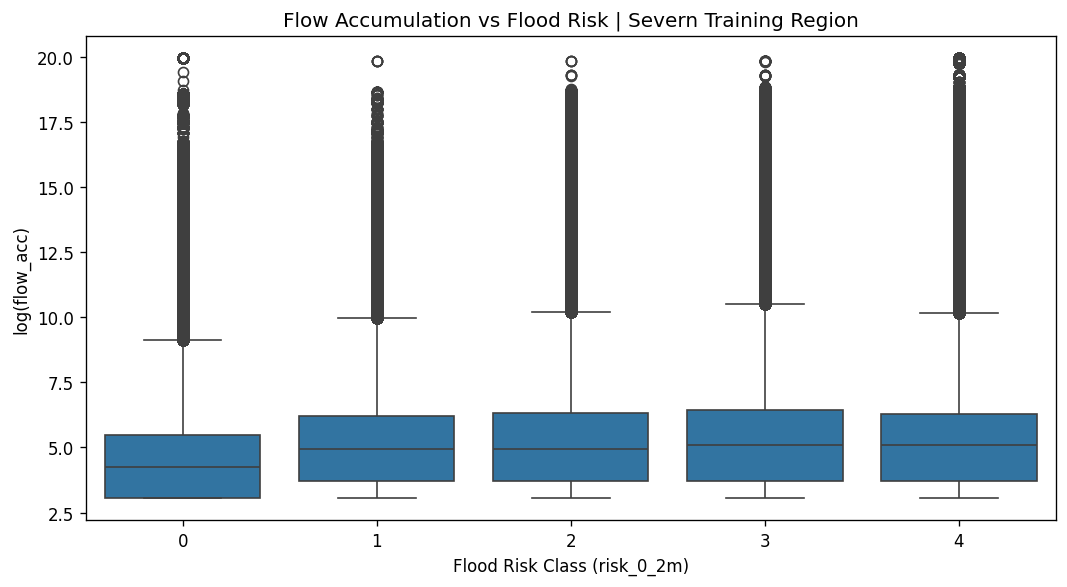

In [10]:
# Use only the columns needed
tmp = severn_df[["risk_0_2m", "log_flow_acc"]].dropna().copy()

# Optional: sample for speed if needed
# tmp = tmp.sample(500_000, random_state=42)

# Make risk classes cleaner for plotting
tmp["risk_0_2m"] = tmp["risk_0_2m"].astype(int)

fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=tmp,
    x="risk_0_2m",
    y="log_flow_acc",
    ax=ax
)

ax.set_title("Flow Accumulation vs Flood Risk | Severn Training Region")
ax.set_xlabel("Flood Risk Class (risk_0_2m)")
ax.set_ylabel("log(flow_acc)")

plt.tight_layout()
plt.show()

## Violin Plot looks better because we have a lot of outliers

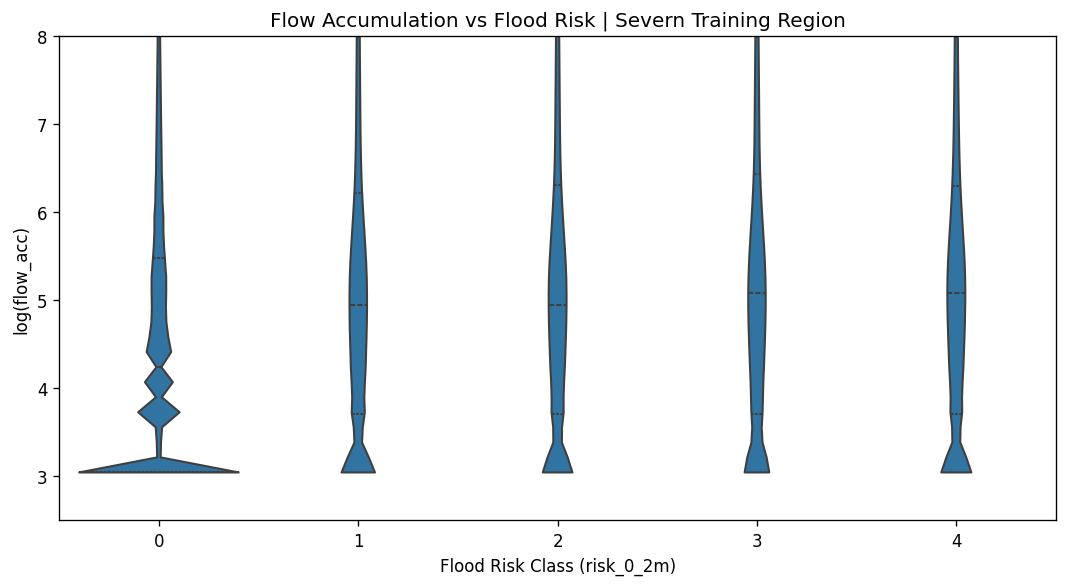

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.violinplot(
    data=tmp,
    x="risk_0_2m",
    y="log_flow_acc",
    cut=0,
    inner="quartile",
    ax=ax
)

# Zoom into meaningful range
ax.set_ylim(2.5, 8)

ax.set_title(
    "Flow Accumulation vs Flood Risk | Severn Training Region"
)

ax.set_xlabel("Flood Risk Class (risk_0_2m)")
ax.set_ylabel("log(flow_acc)")

plt.tight_layout()
plt.show()

Now i plot flood risk vs elevation, the other engineered feature

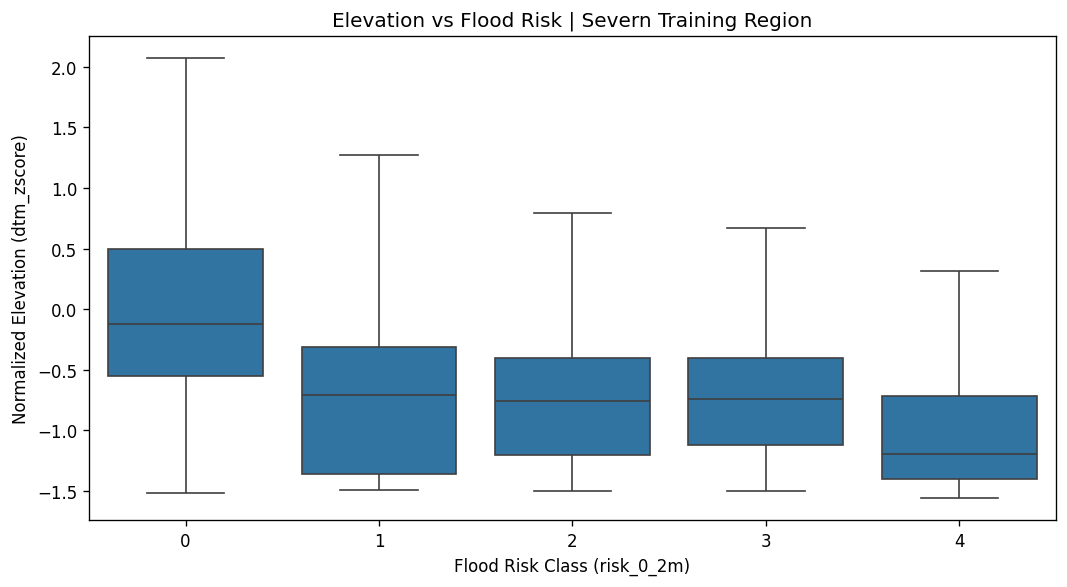

In [14]:
elev_tmp = severn_df[
    ["risk_0_2m", "dtm_zscore"]
].dropna().copy()

#Force classes to integers
elev_tmp["risk_0_2m"] = (
    elev_tmp["risk_0_2m"]
    .astype(int)
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=elev_tmp,
    x="risk_0_2m",
    y="dtm_zscore",
    showfliers=False,
    ax=ax
)

ax.set_title(
    "Elevation vs Flood Risk | Severn Training Region"
)

ax.set_xlabel(
    "Flood Risk Class (risk_0_2m)"
)

ax.set_ylabel(
    "Normalized Elevation (dtm_zscore)"
)

plt.tight_layout()
plt.show()

Higher flood-risk classes tend to occur at lower normalized
elevations, consistent with hydrological expectations that
floodplains and valley systems are more exposed to inundation.
Using normalized elevation (dtm_zscore) instead of raw terrain
height improves transferability across regions with different
topographic scales.